In [4]:
import pandas as pd

In [5]:
# inspect booknow_visits
bv = pd.read_csv('booknow_visits.csv', low_memory=False)
print("booknow_visits shape:", bv.shape)
print(bv.columns.tolist())
display(bv.head())
print(bv.dtypes)
print("Any nulls per column:\n", bv.isnull().sum())

booknow_visits shape: (214046, 3)
['book_theater_id', 'show_date', 'audience_count']


,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


book_theater_id    object
show_date          object
audience_count      int64
dtype: object
Any nulls per column:
 book_theater_id    0
show_date          0
audience_count     0
dtype: int64


In [6]:
bv['show_date'] = pd.to_datetime(bv['show_date'], errors='coerce')
print("bv head/shape:", bv.shape); display(bv.head())

print("unique dates:", bv['show_date'].nunique(), "unique theatres:", bv['book_theater_id'].nunique())

bv head/shape: (214046, 3)


,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


unique dates: 424 unique theatres: 826


In [7]:
per_theatre = bv.groupby('book_theater_id')['audience_count'].median().rename('median_att').reset_index()
print(per_theatre.head()); print("num theatres with history:", per_theatre.shape[0])

  book_theater_id  median_att
0      book_00001        46.0
1      book_00002         9.0
2      book_00003        55.0
3      book_00004        19.0
4      book_00005        50.0
num theatres with history: 826


In [10]:
from sklearn.model_selection import TimeSeriesSplit

In [11]:
bv['show_date'] = pd.to_datetime(bv['show_date'], errors='coerce')
bv = bv.sort_values(['show_date', 'book_theater_id']).reset_index(drop=True)

In [12]:
# date features
bv['day'] = bv['show_date'].dt.day
bv['month'] = bv['show_date'].dt.month
bv['year'] = bv['show_date'].dt.year
bv['dow'] = bv['show_date'].dt.dayofweek

In [13]:
# simple lag (lag1) and roll7 mean (shifted)
bv['lag_1'] = bv.groupby('book_theater_id')['audience_count'].shift(1)
bv['roll7'] = bv.groupby('book_theater_id')['audience_count'].transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())

In [14]:
bv['lag_1'] = bv['lag_1'].fillna(bv['audience_count'].median())
bv['roll7'] = bv['roll7'].fillna(bv['audience_count'].median())

In [15]:
features = ['day','month','year','dow','lag_1','roll7','book_theater_id']
X = bv[features].copy()
y = bv['audience_count'].copy()

In [18]:
import numpy as np
n = X.shape[0]
test_size = int(np.ceil(0.2 * n))
train_size = n - test_size

X_train = X.iloc[:train_size].reset_index(drop=True)
X_test  = X.iloc[train_size:].reset_index(drop=True)
y_train = y.iloc[:train_size].reset_index(drop=True)
y_test  = y.iloc[train_size:].reset_index(drop=True)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (171236, 7) X_test: (42810, 7)


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from scipy import sparse

In [20]:
numeric_cols = ['day','month','year','dow','lag_1','roll7']
categorical_cols = ['book_theater_id']

In [22]:
ct = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols)
], remainder='drop')

In [23]:
X_train_trans = ct.fit_transform(X_train)
X_test_trans  = ct.transform(X_test)

In [24]:
print(type(X_train_trans), X_train_trans.shape)
print(type(X_test_trans), X_test_trans.shape)

<class 'scipy.sparse._csr.csr_matrix'> (171236, 825)
<class 'scipy.sparse._csr.csr_matrix'> (42810, 825)


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [26]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=0.7,
    n_jobs=-1,
    random_state=42
)

In [27]:
rf.fit(X_train_trans, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,0.7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
rf_train_pred = rf.predict(X_train_trans)
rf_test_pred  = rf.predict(X_test_trans)

In [31]:
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_test_rmse  = np.sqrt(mean_squared_error(y_test, rf_test_pred))

In [32]:
print("Train RMSE:", rf_train_rmse)
print("Test  RMSE:", rf_test_rmse)

Train RMSE: 25.375072859151693
Test  RMSE: 23.87185693708135


In [34]:
from xgboost import XGBRegressor

In [35]:
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.5,
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)

In [36]:
xgb.fit(X_train_trans, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [37]:
xgb_train_pred = xgb.predict(X_train_trans)
xgb_test_pred  = xgb.predict(X_test_trans)

In [38]:
xgb_train_rmse = mean_squared_error(y_train, xgb_train_pred)
xgb_test_rmse  = mean_squared_error(y_test, xgb_test_pred)

In [39]:
print("Train RMSE:", xgb_train_rmse)
print("Test  RMSE:", xgb_test_rmse)

Train RMSE: 603.2813720703125
Test  RMSE: 531.07275390625


In [40]:
"""from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from lightgbm import LGBMRegressor

# estimator (GPU)
lgbm = LGBMRegressor(objective='regression', device='gpu', verbose=-1, random_state=42)

# RandomizedSearchCV (n_jobs=1 so GPU isn't oversubscribed)
rs = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,   # same param_dist you prepared
    n_iter=40,                        # change as you wish
    scoring='neg_root_mean_squared_error',  # or your metric
    cv=TimeSeriesSplit(n_splits=5),
    verbose=2,
    random_state=42,
    n_jobs=1
)

print("Starting RandomizedSearchCV (no early stopping passed).")
rs.fit(X_train_trans, y_train)   # <-- NO extra fit_params
print("Done. Best params:")
print(rs.best_params_)
print("Best CV score (neg RMSE):", rs.best_score_)"""

'from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit\nfrom lightgbm import LGBMRegressor\n\n# estimator (GPU)\nlgbm = LGBMRegressor(objective=\'regression\', device=\'gpu\', verbose=-1, random_state=42)\n\n# RandomizedSearchCV (n_jobs=1 so GPU isn\'t oversubscribed)\nrs = RandomizedSearchCV(\n    estimator=lgbm,\n    param_distributions=param_dist,   # same param_dist you prepared\n    n_iter=40,                        # change as you wish\n    scoring=\'neg_root_mean_squared_error\',  # or your metric\n    cv=TimeSeriesSplit(n_splits=5),\n    verbose=2,\n    random_state=42,\n    n_jobs=1\n)\n\nprint("Starting RandomizedSearchCV (no early stopping passed).")\nrs.fit(X_train_trans, y_train)   # <-- NO extra fit_params\nprint("Done. Best params:")\nprint(rs.best_params_)\nprint("Best CV score (neg RMSE):", rs.best_score_)'

In [42]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [43]:
best_params = {
    'colsample_bytree': 0.5943535541706897,
    'learning_rate': 0.09366140577765455,
    'max_depth': 8,
    'min_child_samples': 52,
    'n_estimators': 307,
    'num_leaves': 150,
    'subsample': 0.942529716751237
}

In [44]:
best_native = best_params.copy()
best_native.update({
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'seed': 42,
})

In [45]:
dtrain = lgb.Dataset(X_train_trans, label=y_train)
dvalid = lgb.Dataset(X_test_trans, label=y_test, reference=dtrain)

In [46]:
num_boost_round = 2000
early_stop = 100

In [47]:
bst = lgb.train(
    params=best_native,
    train_set=dtrain,
    num_boost_round=num_boost_round,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=early_stop),
        lgb.log_evaluation(period=50)
    ],
)

Training until validation scores don't improve for 100 rounds
[50]	train's rmse: 23.8868	valid's rmse: 23.1719
[100]	train's rmse: 23.628	valid's rmse: 23.1013
[150]	train's rmse: 23.4659	valid's rmse: 23.0445
[200]	train's rmse: 23.3307	valid's rmse: 23.0216
[250]	train's rmse: 23.2369	valid's rmse: 23.0122
[300]	train's rmse: 23.1378	valid's rmse: 22.9918
Did not meet early stopping. Best iteration is:
[304]	train's rmse: 23.1287	valid's rmse: 22.9848


In [48]:
print("Best iteration:", bst.best_iteration)

Best iteration: 304


In [50]:
y_pred_test = bst.predict(X_test_trans, num_iteration=bst.best_iteration)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Holdout/Test RMSE: {rmse_test:.4f}    MAE: {mae_test:.4f}")

Holdout/Test RMSE: 22.9848    MAE: 16.0107


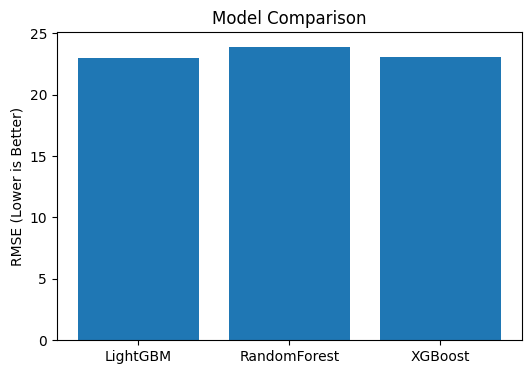

In [54]:
import matplotlib.pyplot as plt

rmse_vals = [
    np.sqrt(mean_squared_error(y_test, y_pred_test)),   # LightGBM
    np.sqrt(mean_squared_error(y_test, rf_test_pred)),  # RandomForest
    np.sqrt(mean_squared_error(y_test, xgb_test_pred))  # XGBoost
]

models = ['LightGBM', 'RandomForest', 'XGBoost']

plt.figure(figsize=(6,4))
plt.bar(models, rmse_vals)
plt.ylabel("RMSE (Lower is Better)")
plt.title("Model Comparison")
plt.show()

Threshold used for classification (Median): 34.00


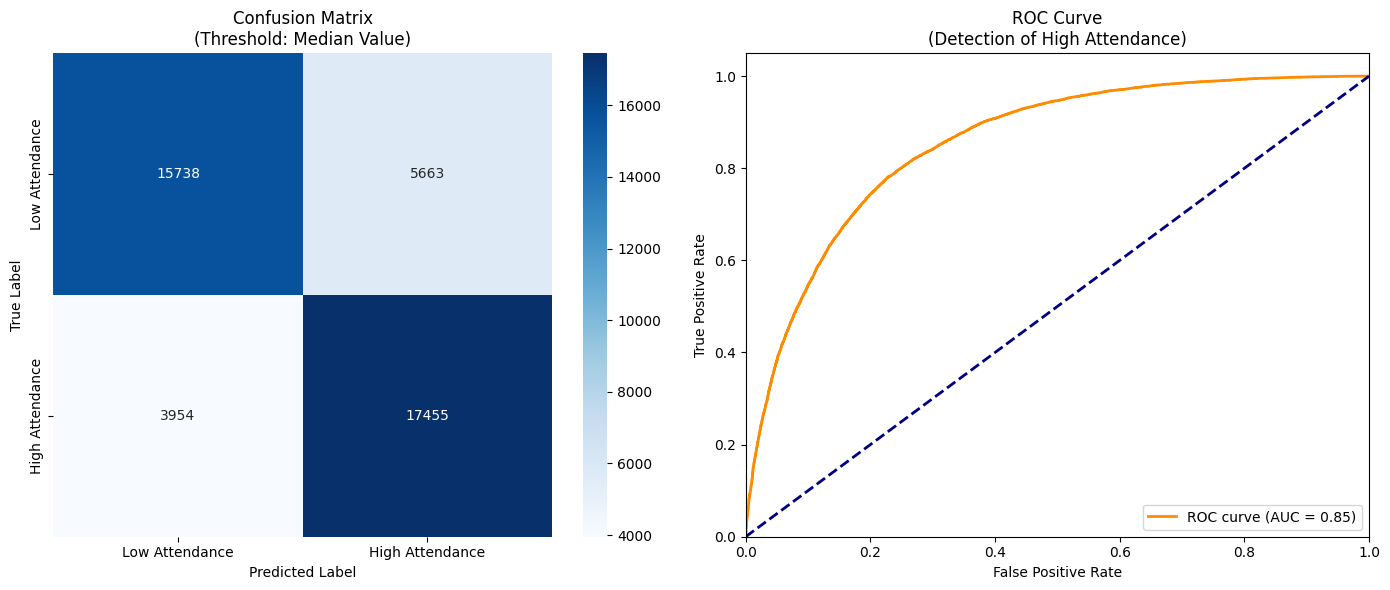


Classification Report (High vs Low Attendance):
              precision    recall  f1-score   support

         Low       0.80      0.74      0.77     21401
        High       0.76      0.82      0.78     21409

    accuracy                           0.78     42810
   macro avg       0.78      0.78      0.77     42810
weighted avg       0.78      0.78      0.77     42810



In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# ==========================================
# 1. Convert Regression to Classification
# ==========================================
# We define a "High Attendance" day as any day with attendance above the median.
threshold = y_test.median()
print(f"Threshold used for classification (Median): {threshold:.2f}")

# Create binary targets (1 = High Attendance, 0 = Low Attendance)
y_test_binary = (y_test >= threshold).astype(int)       # Actual Binary
y_pred_binary = (y_pred_test >= threshold).astype(int)  # Predicted Binary (for Confusion Matrix)

# ==========================================
# 2. Plotting
# ==========================================
plt.figure(figsize=(14, 6))

# --- PLOT 1: Confusion Matrix ---
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test_binary, y_pred_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Attendance', 'High Attendance'], 
            yticklabels=['Low Attendance', 'High Attendance'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix\n(Threshold: Median Value)')

# --- PLOT 2: ROC Curve ---
plt.subplot(1, 2, 2)
# We use the raw regression predictions (y_pred_test) as the "score" 
# because higher predicted numbers correlate with the positive class (High Attendance).
fpr, tpr, _ = roc_curve(y_test_binary, y_pred_test)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve\n(Detection of High Attendance)')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# --- OPTIONAL: Text Report ---
print("\nClassification Report (High vs Low Attendance):")
print(classification_report(y_test_binary, y_pred_binary, target_names=['Low', 'High']))